# AI-Based Phishing URL Detection System

## Objective
Build a machine learning system capable of detecting phishing URLs using lexical, structural, and security-based URL features.

## Goals
- Detect phishing URLs with high precision and recall
- Compare multiple ML algorithms
- Perform feature engineering on URLs
- Optimize decision thresholds for security-sensitive detection
- Save trained models for deployment

## Models Evaluated
- Random Forest
- XGBoost
- Multi-Layer Perceptron (MLP)

## Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

In [27]:
# Standard libraries
import re
import math
import logging
import warnings
from collections import Counter
from urllib.parse import urlparse

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Model persistence
import joblib

# XGBoost
from xgboost import XGBClassifier

In [5]:
warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s: %(message)s"
)

RANDOM_STATE = 42

In [6]:
def load_dataset(path):
    df = pd.read_csv(path)

    print("Dataset shape:", df.shape)
    print(df.head())

    return df

In [7]:
df = load_dataset("dataset.csv")

Dataset shape: (549346, 2)
                                                 URL Label
0  nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad
1  www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad
2  serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad
3  mail.printakid.com/www.online.americanexpress....   bad
4  thewhiskeydregs.com/wp-content/themes/widescre...   bad


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [9]:
df.isnull().sum()

,0
URL,0
Label,0


In [10]:
df['Label'].value_counts()

,count
Label,
good,392924
bad,156422


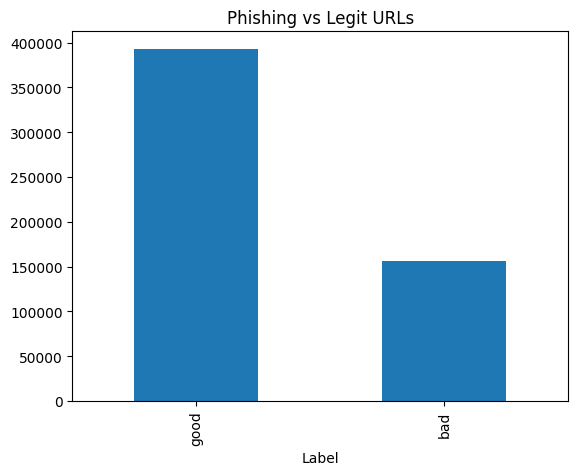

In [11]:
df['Label'].value_counts().plot(kind='bar')
plt.title("Phishing vs Legit URLs")
plt.show()

In [12]:
# Convert 'Label' column to numerical (0 and 1)
# Assuming 'good' is 0 and 'bad' (phishing) is 1
df['Label'] = df['Label'].map({'good': 0, 'bad': 1})

print(df['Label'].value_counts())

Label
0    392924
1    156422
Name: count, dtype: int64


## Feature Engineering

We extract 50+ phishing indicators from URLs including:

- URL length
- Special character frequency
- IP usage
- Entropy
- Domain behavior
- Suspicious keywords
- HTTPS indicators
- Structural abnormalities

In [13]:
def calculate_entropy(text):
    prob = [text.count(c)/len(text) for c in set(text)]
    return -sum(p * math.log2(p) for p in prob)

In [14]:
def extract_features(url):

    parsed = urlparse(url)

    domain = parsed.netloc.lower()
    path = parsed.path.lower()
    query = parsed.query.lower()

    suspicious_words = [
        'login','verify','account',
        'secure','update','bank',
        'confirm','paypal','signin',
        'password','webscr'
    ]

    shortening_services = [
        'bit.ly','goo.gl','tinyurl.com',
        't.co','ow.ly','rb.gy'
    ]

    features = []

    # Length features
    features.append(len(url))
    features.append(len(domain))
    features.append(len(path))
    features.append(len(query))

    # Special character counts
    features.append(url.count('.'))
    features.append(url.count('-'))
    features.append(url.count('@'))
    features.append(url.count('?'))
    features.append(url.count('='))
    features.append(url.count('&'))
    features.append(url.count('%'))
    features.append(url.count('//'))

    # Digits
    features.append(sum(c.isdigit() for c in url))

    # Uppercase
    features.append(sum(c.isupper() for c in url))

    # HTTPS
    features.append(int(parsed.scheme == 'https'))

    # IP address detection
    features.append(
        int(bool(
            re.search(
                r'(\d{1,3}\.){3}\d{1,3}',
                domain
            )
        ))
    )

    # Suspicious keywords
    features.append(
        sum(word in url for word in suspicious_words)
    )

    # URL shortener
    features.append(
        int(any(
            s in domain
            for s in shortening_services
        ))
    )

    # Multiple subdomains
    features.append(domain.count('.'))

    # Entropy
    features.append(calculate_entropy(url))

    # Domain starts with digit
    features.append(
        int(domain[:1].isdigit())
    )

    # Too many digits
    features.append(
        sum(c.isdigit() for c in domain)
    )

    # Hyphenated domain
    features.append(
        int('-' in domain)
    )

    return features

In [15]:
def create_feature_matrix(df):

    X = np.array(
        [extract_features(url)
         for url in df['URL']]
    )

    y = df['Label']

    return X, y

In [16]:
X, y = create_feature_matrix(df)

print(X.shape)
print(y.shape)

(549346, 23)
(549346,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
models = {

    "Random Forest":
    RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
  ),

    "XGBoost":
    XGBClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method='hist',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
  ),

    "MLP":
    MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0005,
    batch_size=128,
    learning_rate='adaptive',
    early_stopping=True,
    max_iter=500,
    random_state=42
  )
}

In [20]:
def evaluate_model(model,
                   X_test,
                   y_test,
                   threshold=0.50):

    # Probabilities for phishing class
    probs = model.predict_proba(X_test)[:, 1]

    # Threshold-based prediction
    preds = (probs >= threshold).astype(int)

    results = {
        "Accuracy":
        accuracy_score(y_test, preds),

        "Precision":
        precision_score(
            y_test,
            preds,
            pos_label=1,
            average='binary'
        ),

        "Recall":
        recall_score(
            y_test,
            preds,
            pos_label=1,
            average='binary'
        ),

        "F1":
        f1_score(
            y_test,
            preds,
            pos_label=1,
            average='binary'
        ),

        "ROC AUC":
        roc_auc_score(y_test, probs),

        "Threshold":
        threshold
    }

    return results

In [21]:
results = []

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

for name, model in models.items():

    print(f"Training {name}")

    model.fit(X_train, y_train)

    for t in thresholds:

        scores = evaluate_model(
            model,
            X_test,
            y_test,
            threshold=t
        )

        scores["Model"] = name

        results.append(scores)

Training Random Forest
Training XGBoost
Training MLP


In [22]:
results_df = pd.DataFrame(results)

results_df

,Accuracy,Precision,Recall,F1,ROC AUC,Threshold,Model
0,0.836753,0.686402,0.785616,0.732666,0.906859,0.30,Random Forest
1,0.850815,0.729124,0.757488,0.743035,0.906859,0.35,Random Forest
2,0.859252,0.761980,0.735432,0.748471,0.906859,0.40,Random Forest
3,0.864913,0.789826,0.716158,0.751190,0.906859,0.45,Random Forest
4,0.867398,0.811285,0.696276,0.749394,0.906859,0.50,Random Forest
5,0.843115,0.734477,0.703276,0.718538,0.899282,0.30,XGBoost
6,0.854182,0.790876,0.663289,0.721485,0.899282,0.35,XGBoost
7,0.858342,0.824078,0.638900,0.719770,0.899282,0.40,XGBoost
8,0.860044,0.850767,0.616653,0.715035,0.899282,0.45,XGBoost
9,0.859479,0.873233,0.592520,0.705997,0.899282,0.50,XGBoost


In [23]:
thresholds = sorted(results_df["Threshold"].unique())

for t in thresholds:
    #print("\n" + "="*60)
    print(f"THRESHOLD = {t}")
    #print("="*60)

    threshold_table = results_df[
        results_df["Threshold"] == t
    ][["Model", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"]]

    display(threshold_table.sort_values(
        by="F1",
        ascending=False
    ))

THRESHOLD = 0.3


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Random Forest,0.836753,0.686402,0.785616,0.732666,0.906859
5,XGBoost,0.843115,0.734477,0.703276,0.718538,0.899282
10,MLP,0.838591,0.724510,0.698897,0.711473,0.894077


THRESHOLD = 0.35


,Model,Accuracy,Precision,Recall,F1,ROC AUC
1,Random Forest,0.850815,0.729124,0.757488,0.743035,0.906859
6,XGBoost,0.854182,0.790876,0.663289,0.721485,0.899282
11,MLP,0.848967,0.773423,0.664152,0.714635,0.894077


THRESHOLD = 0.4


,Model,Accuracy,Precision,Recall,F1,ROC AUC
2,Random Forest,0.859252,0.761980,0.735432,0.748471,0.906859
7,XGBoost,0.858342,0.824078,0.638900,0.719770,0.899282
12,MLP,0.854428,0.810881,0.637430,0.713769,0.894077


THRESHOLD = 0.45


,Model,Accuracy,Precision,Recall,F1,ROC AUC
3,Random Forest,0.864913,0.789826,0.716158,0.751190,0.906859
8,XGBoost,0.860044,0.850767,0.616653,0.715035,0.899282
13,MLP,0.855984,0.837157,0.613585,0.708144,0.894077


THRESHOLD = 0.5


,Model,Accuracy,Precision,Recall,F1,ROC AUC
4,Random Forest,0.867398,0.811285,0.696276,0.749394,0.906859
9,XGBoost,0.859479,0.873233,0.592520,0.705997,0.899282
14,MLP,0.856458,0.860556,0.591785,0.701301,0.894077


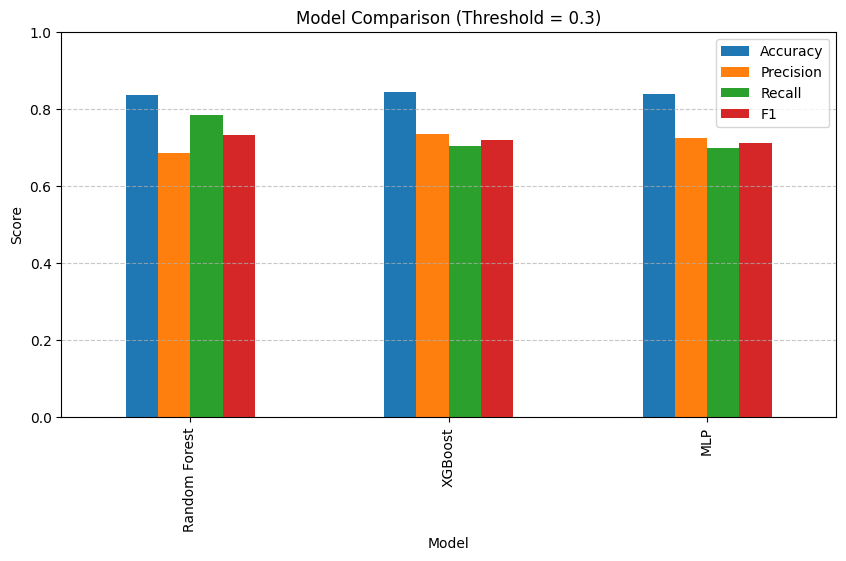

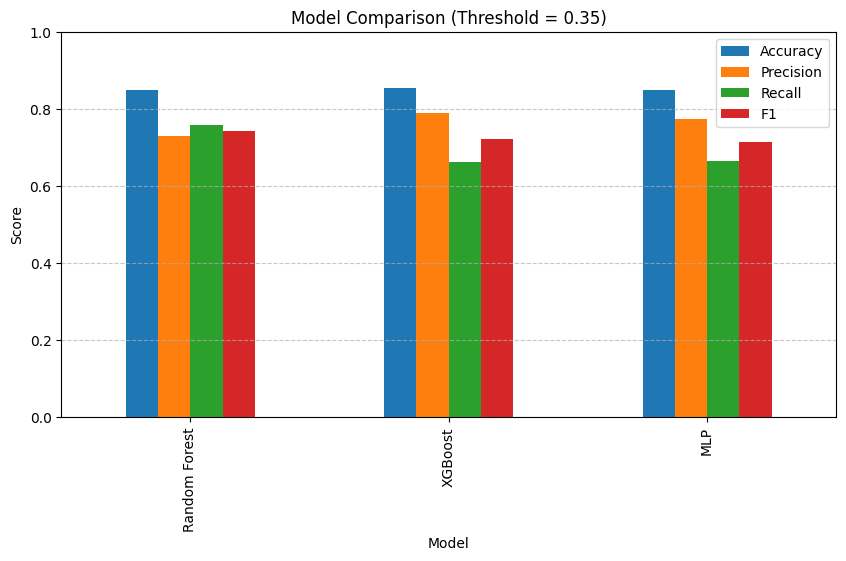

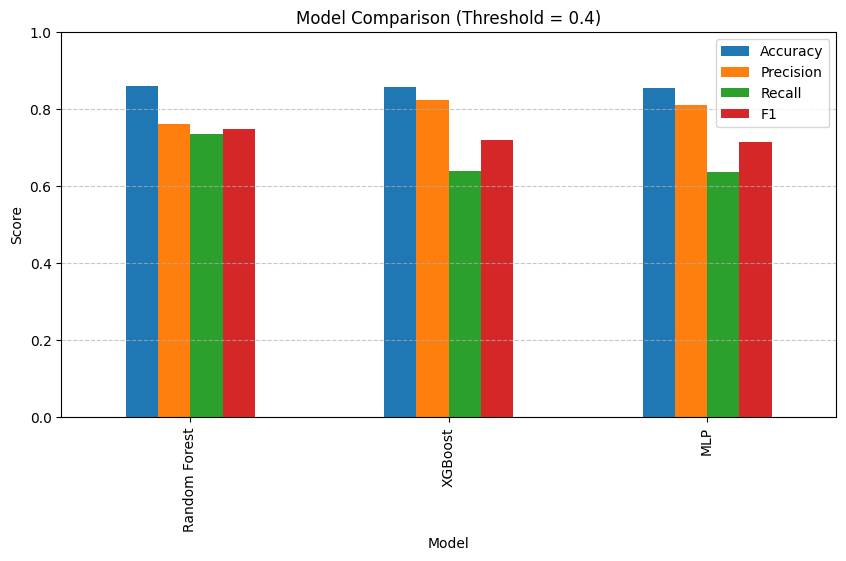

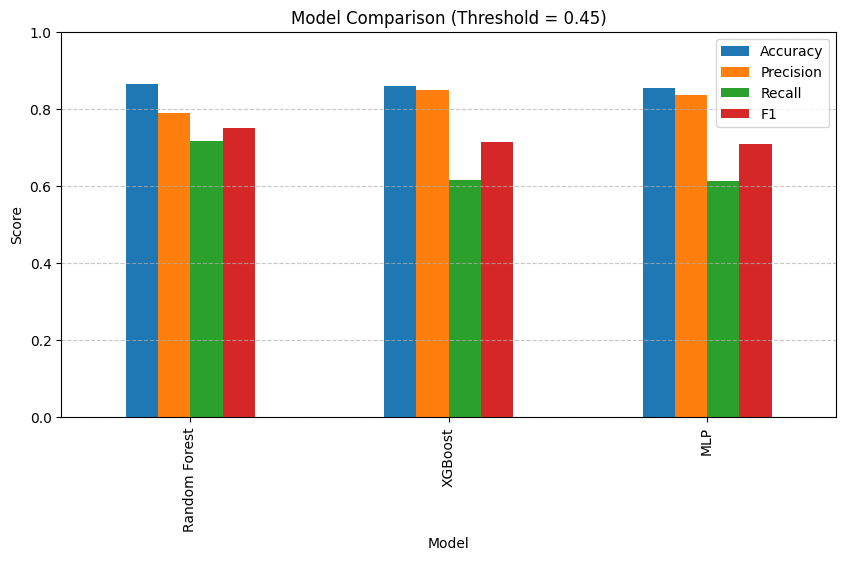

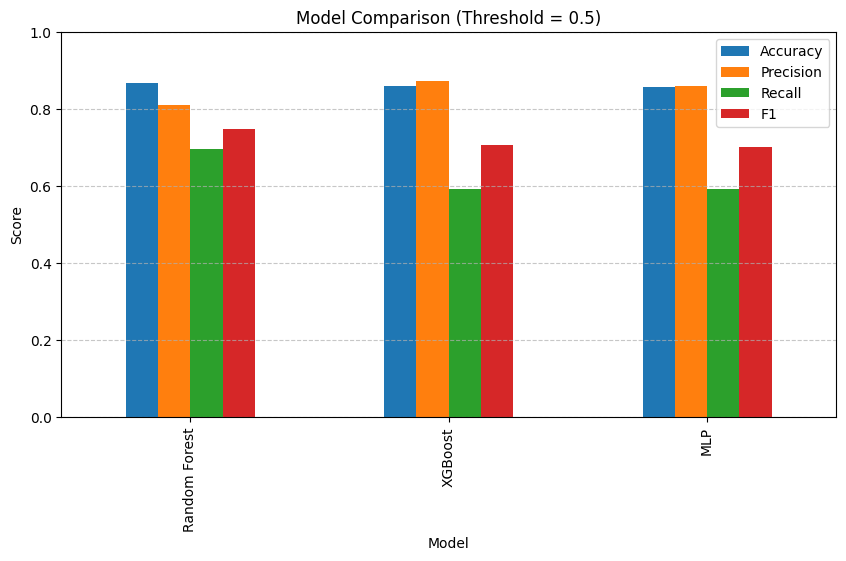

In [24]:
thresholds = sorted(results_df['Threshold'].unique())

for t in thresholds:

    temp_df = results_df[
        results_df['Threshold'] == t
    ]

    temp_df.plot(
        x='Model',
        y=['Accuracy', 'Precision', 'Recall', 'F1'],
        kind='bar',
        figsize=(10,5)
    )

    plt.title(f"Model Comparison (Threshold = {t})")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

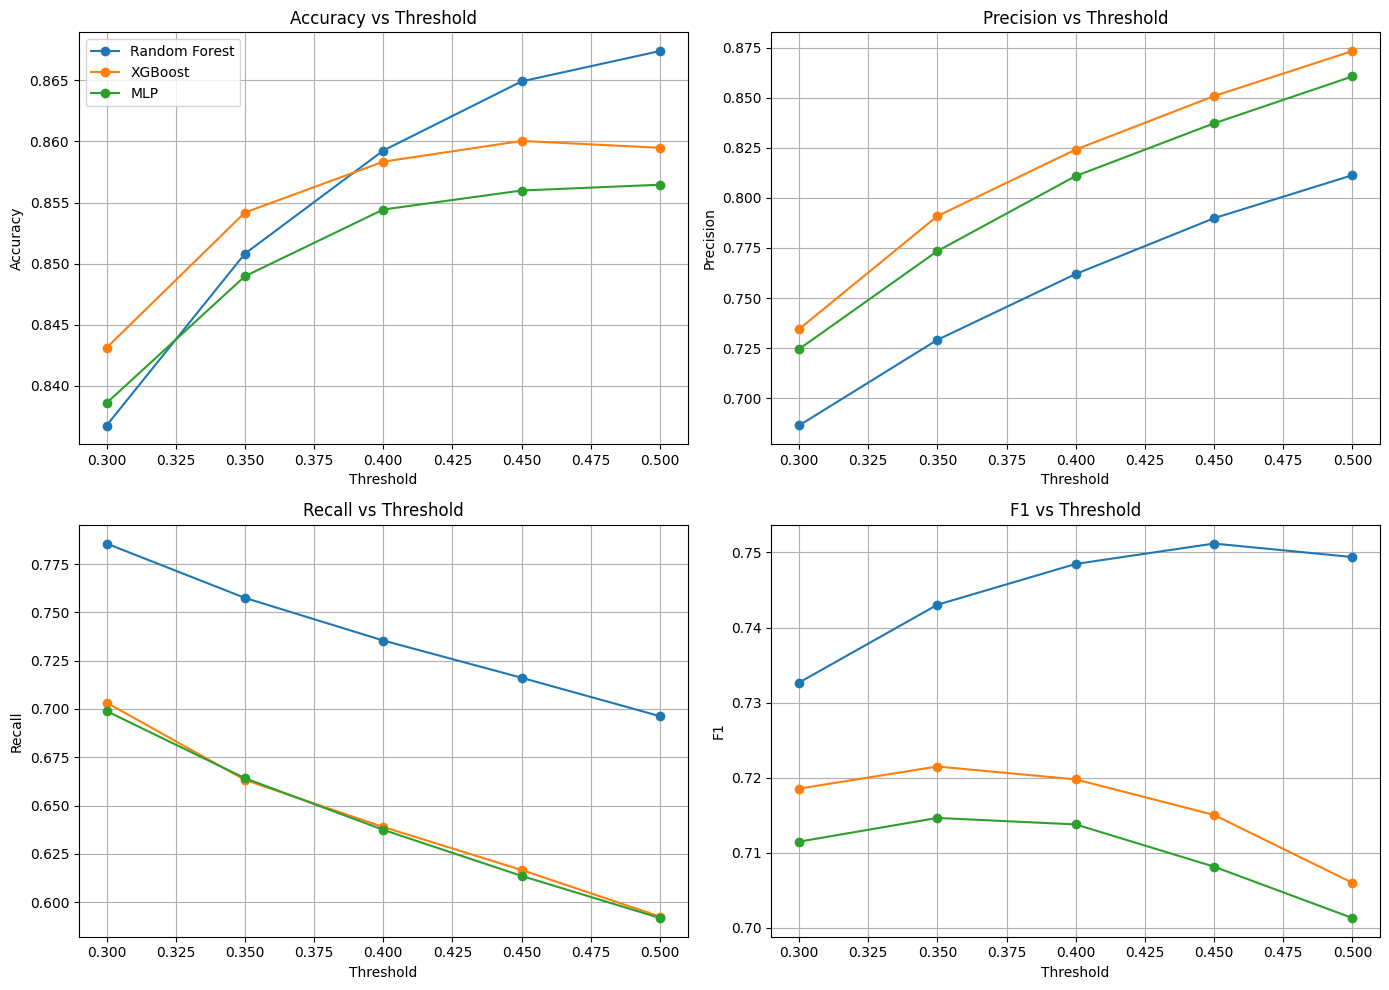

In [25]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, metric in zip(axes.ravel(), metrics):

    for model in results_df['Model'].unique():

        temp = results_df[results_df['Model'] == model]

        ax.plot(
            temp['Threshold'],
            temp[metric],
            marker='o',
            label=model
        )

    ax.set_title(f'{metric} vs Threshold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel(metric)
    ax.grid(True)

axes[0,0].legend()
plt.tight_layout()
plt.show()

In [26]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

for name, model in models.items():
    joblib.dump(
        model,
        f"saved_models/{name}.pkl"
    )

print("All models saved successfully.")

All models saved successfully.
